# Solar Photovoltaic Energy

## Learning goals

After this lesson you should be able to:

- distinguish irradiance, irradiation, power, energy, efficiency, and performance ratio;
- estimate cell temperature and temperature-corrected DC power;
- model inverter clipping and aggregate hourly energy;
- build reusable scalar-and-array Python functions;
- plot a solar day, a sensitivity surface, and monthly energy;
- state the limits of a simplified PV model.

A photovoltaic (PV) cell converts part of incident solar radiation directly into DC electricity. An inverter converts DC to grid-compatible AC. Irradiance and cell temperature affect instantaneous output; shading, soiling, wiring, mismatch, inverter behavior, availability, and degradation affect delivered energy. Standard Test Conditions (STC) use 1000 W/m$^2$ irradiance, 25 °C cell temperature and the AM1.5 reference spectrum [@doePVPerformance; @doePVLongevity].

## Concepts and equations

### Irradiance versus irradiation

- **Irradiance** $G$ is instantaneous power per area, W/m$^2$.
- **Irradiation** is irradiance integrated over time, commonly kWh/m$^2$.

Do not label an hourly sum of irradiance values as W/m$^2$; after multiplying by the time step it is an energy-per-area quantity.

### From solar resource to PV power

For area $A$ and conversion efficiency $\eta$:

$$P_{DC}=GA\eta$$

For a rated array, a convenient first-order model is

$$P_{DC}=P_{STC}\frac{G}{G_{STC}}
\left[1+\gamma_P(T_c-25)\right]$$

where $\gamma_P$ is normally negative and $T_c$ is cell temperature in °C. A simple NOCT approximation is

$$T_c=T_a+\frac{G}{800}(NOCT-20)$$

This is a teaching model, not a bankable performance model. The temperature equation is an empirical approximation and should not be extrapolated carelessly.

### AC output and energy

With inverter efficiency $\eta_{inv}$ and AC rating $P_{AC,r}$:

$$P_{AC}=\min(P_{DC}\eta_{inv},P_{AC,r})$$

For hourly samples:

$$E_{AC}=\sum_i P_{AC,i}\Delta t_i$$

Performance ratio (PR) is a normalized energy-quality indicator. One common definition is

$$PR=\frac{E_{AC}/P_{rated}}{H_{POA}/G_{STC}}$$

where $H_{POA}$ is plane-of-array irradiation and $P_{rated}$ is the DC nameplate rating at STC. Use consistent kW/kWh or MW/MWh units; $G_{STC}=1$ kW/m². State the exact convention because PR boundaries can differ.

## Tested Python functions

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def cell_temperature_c(irradiance_wm2, ambient_c, noct_c=45.0):
    """Simplified NOCT cell-temperature estimate."""
    if not all(np.isfinite(np.asarray(value, dtype=float)).all() for value in [irradiance_wm2, ambient_c, noct_c]):
        raise ValueError("model inputs must be finite")
    irradiance = np.asarray(irradiance_wm2, dtype=float)
    if np.any(irradiance < 0):
        raise ValueError("irradiance must be non-negative")
    return np.asarray(ambient_c, dtype=float) + irradiance / 800 * (noct_c - 20)

def pv_ac_power_mw(irradiance_wm2, ambient_c, dc_rating_mw,
                   ac_rating_mw, gamma_p=-0.004, noct_c=45.0,
                   inverter_efficiency=0.97):
    """Simplified temperature-corrected PV output, clipped at AC rating."""
    if not all(np.isfinite(np.asarray(value, dtype=float)).all() for value in [dc_rating_mw, ac_rating_mw, gamma_p, inverter_efficiency]):
        raise ValueError("model inputs must be finite")
    if dc_rating_mw < 0 or ac_rating_mw < 0:
        raise ValueError("ratings must be non-negative")
    if not 0 < inverter_efficiency <= 1:
        raise ValueError("inverter_efficiency must be in (0, 1]")
    irradiance = np.asarray(irradiance_wm2, dtype=float)
    cell_c = cell_temperature_c(irradiance, ambient_c, noct_c)
    temperature_factor = np.maximum(1 + gamma_p * (cell_c - 25), 0)
    dc_power = dc_rating_mw * irradiance / 1000 * temperature_factor
    ac_power = np.minimum(dc_power * inverter_efficiency, ac_rating_mw)
    return float(ac_power) if ac_power.ndim == 0 else ac_power

assert pv_ac_power_mw(0, 25, 10, 8) == 0
assert 0 <= pv_ac_power_mw(1000, 25, 10, 8) <= 8

### Why the checks matter

Input validation stops physically impossible negative irradiance and invalid efficiency values. `np.asarray` lets the same function accept a number, list, or NumPy array. `np.maximum` prevents a linear temperature approximation from producing negative power outside its valid range.

## Worked solar-day example

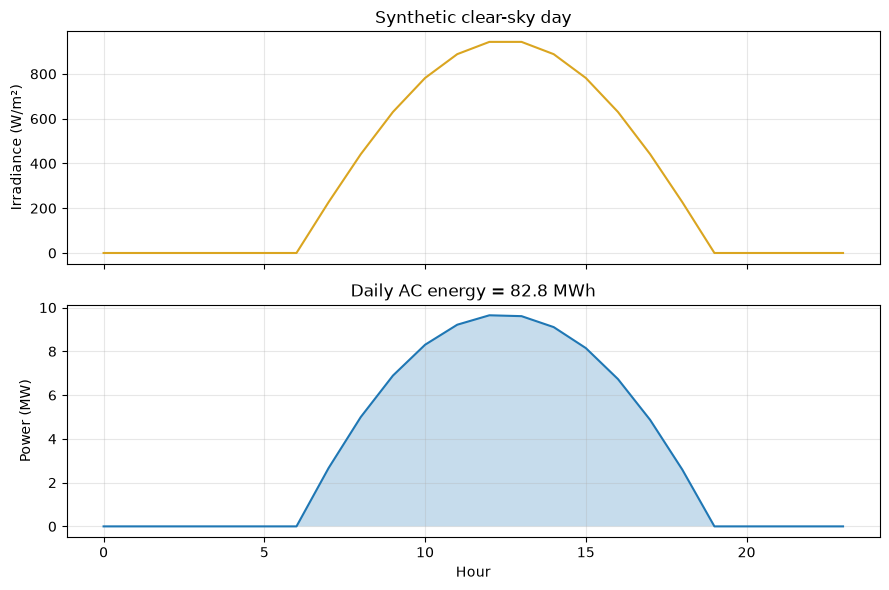

In [2]:
hours = np.arange(24)
sunrise, sunset = 6, 19
daylight = (hours >= sunrise) & (hours <= sunset)
irradiance = np.zeros_like(hours, dtype=float)
irradiance[daylight] = 950 * np.sin(
    np.pi * (hours[daylight] - sunrise) / (sunset - sunrise)
)
irradiance = np.clip(irradiance, 0, None)  # remove floating-point noise at sunset
ambient_c = 18 + 9 * np.sin(2 * np.pi * (hours - 8) / 24)
cell_c = cell_temperature_c(irradiance, ambient_c)
power_mw = pv_ac_power_mw(irradiance, ambient_c, 12, 10)
daily_energy_mwh = power_mw.sum()  # one-hour intervals

fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)
axes[0].plot(hours, irradiance, label="Irradiance", color="goldenrod")
axes[0].set(ylabel="Irradiance (W/m²)", title="Synthetic clear-sky day")
axes[0].grid(alpha=0.3)
axes[1].plot(hours, power_mw, label="AC power", color="tab:blue")
axes[1].fill_between(hours, power_mw, alpha=0.25)
axes[1].set(xlabel="Hour", ylabel="Power (MW)",
            title=f"Daily AC energy = {daily_energy_mwh:.1f} MWh")
axes[1].grid(alpha=0.3)
plt.tight_layout()

Because each sample represents one hour, summing MW values yields MWh. With 15-minute data, multiply the sum by 0.25 h.


[Download this complete chapter as a Jupyter notebook](solarEnergy.ipynb). In standard Jupyter viewers, answer headings and code are visible below each prompt; the book provides collapse controls.

## Chapter practice — 20 Python exercises

**5 easy · 10 medium · 5 hard.** Work through the exercises in order. All inputs are synthetic teaching data. Each solution is directly below its question and starts collapsed in the book. Open it after trying your own code. Each solution runs independently; run the full notebook from the first cell when studying the chapter. References identify the underlying concepts rather than copied textbook problems.

### Exercise 01 — Panel DC power

**Difficulty:** Easy

**Reference:** PV conversion and systems: [@foster2010; @wade2003]; temperature model [@pvlibDocs].

**Task:** At 800 W/m², a 2 m² panel has efficiency 20%. Calculate DC watts.

In [3]:
# Your solution for solar exercise 01.

#### Step-by-step answer — Solar 01

1. Store irradiance, area and efficiency.
2. Multiply incident power by conversion efficiency.
3. Label and verify the result.

In [4]:
# Step 1: Store irradiance, area and efficiency.
g, area, eta = 800, 2, 0.20
# Step 2: Multiply incident power by conversion efficiency.
power_w = g*area*eta
# Step 3: Label and verify the result.
print(power_w, 'W DC'); assert power_w == 320

320.0 W DC


**Interpretation:** 320 W assumes constant efficiency and uniform irradiance.


### Exercise 02 — Array nameplate

**Difficulty:** Easy

**Reference:** PV conversion and systems: [@foster2010; @wade2003]; temperature model [@pvlibDocs].

**Task:** An array contains 24 modules rated at 400 W DC. Calculate its STC rating in kW.

In [5]:
# Your solution for solar exercise 02.

#### Step-by-step answer — Solar 02

1. Enter module count and rating.
2. Add module ratings and convert to kW.
3. Print and check the nameplate.

In [6]:
# Step 1: Enter module count and rating.
count, module_w = 24, 400
# Step 2: Add module ratings and convert to kW.
array_kw = count*module_w/1000
# Step 3: Print and check the nameplate.
print(array_kw,'kW DC'); assert array_kw == 9.6

9.6 kW DC


**Interpretation:** Nameplate describes STC; actual operating output varies.


### Exercise 03 — Daily irradiation

**Difficulty:** Easy

**Reference:** PV conversion and systems: [@foster2010; @wade2003]; temperature model [@pvlibDocs].

**Task:** Four hourly mean irradiances are 0,200,600,400 W/m². Calculate four-hour irradiation in kWh/m².

In [7]:
# Your solution for solar exercise 03.

#### Step-by-step answer — Solar 03

1. Store hourly means and duration.
2. Integrate and convert Wh to kWh.
3. Verify and label the four-hour result.

In [8]:
# Step 1: Store hourly means and duration.
irradiance = [0,200,600,400]; hours = 1
# Step 2: Integrate and convert Wh to kWh.
irradiation = sum(irradiance)*hours/1000
# Step 3: Verify and label the four-hour result.
print(irradiation,'kWh/m²'); assert irradiation == 1.2

1.2 kWh/m²


**Interpretation:** This is a four-hour window, not necessarily a complete day.


### Exercise 04 — Inverter conversion

**Difficulty:** Easy

**Reference:** PV conversion and systems: [@foster2010; @wade2003]; temperature model [@pvlibDocs].

**Task:** A PV array delivers 5 kW DC to a 96%-efficient inverter with a 6 kW AC limit. Find AC kW.

In [9]:
# Your solution for solar exercise 04.

#### Step-by-step answer — Solar 04

1. Enter the DC input and equipment assumptions.
2. Apply conversion efficiency and the output limit.
3. Check the output cannot exceed input or rating.

In [10]:
# Step 1: Enter the DC input and equipment assumptions.
dc_kw, efficiency, rating_kw = 5, 0.96, 6
# Step 2: Apply conversion efficiency and the output limit.
ac_kw = min(dc_kw*efficiency, rating_kw)
# Step 3: Check the output cannot exceed input or rating.
print(ac_kw,'kW AC'); assert ac_kw == 4.8 and ac_kw <= dc_kw

4.8 kW AC


**Interpretation:** No clipping occurs in this example; efficiency is held constant.


### Exercise 05 — Capacity factor from AC energy

**Difficulty:** Easy

**Reference:** PV conversion and systems: [@foster2010; @wade2003]; temperature model [@pvlibDocs].

**Task:** A 10 kW AC plant exports 48 kWh in 24 hours. Calculate AC-based CF and state the denominator.

In [11]:
# Your solution for solar exercise 05.

#### Step-by-step answer — Solar 05

1. Set exported energy, AC capacity and duration.
2. Calculate the AC-based capacity factor.
3. Print a labelled percentage.

In [12]:
# Step 1: Set exported energy, AC capacity and duration.
energy_kwh, capacity_kw, hours = 48, 10, 24
# Step 2: Calculate the AC-based capacity factor.
cf = energy_kwh/(capacity_kw*hours)
# Step 3: Print a labelled percentage.
print(f'AC-based CF: {cf:.0%}'); assert cf == 0.2

AC-based CF: 20%


**Interpretation:** 20% uses AC nameplate. A DC-based capacity factor would have a different denominator.


### Exercise 06 — Cell-temperature estimate

**Difficulty:** Medium

**Reference:** PV conversion and systems: [@foster2010; @wade2003]; temperature model [@pvlibDocs].

**Task:** At ambient 25 °C and irradiance [0,400,800] W/m², use NOCT 45 °C and Tc=Ta+G(NOCT−20)/800. Calculate temperatures.

In [13]:
# Your solution for solar exercise 06.

#### Step-by-step answer — Solar 06

1. Store irradiance and temperature parameters.
2. Apply the approximate NOCT relationship.
3. Verify the 800 W/m² case.

In [14]:
import numpy as np
# Step 1: Store irradiance and temperature parameters.
g = np.array([0,400,800]); ambient = 25; noct = 45
# Step 2: Apply the approximate NOCT relationship.
cell = ambient+g*(noct-20)/800
# Step 3: Verify the 800 W/m² case.
print(cell,'°C'); assert np.allclose(cell,[25,37.5,50])

[25.  37.5 50. ] °C


**Interpretation:** This simple thermal relationship omits wind and mounting effects.


### Exercise 07 — Temperature coefficient

**Difficulty:** Medium

**Reference:** PV conversion and systems: [@foster2010; @wade2003]; temperature model [@pvlibDocs].

**Task:** At 1000 W/m², a 10 kW STC array has gamma −0.004/°C. Evaluate DC output at cell temperatures [25,45,65]°C.

In [15]:
# Your solution for solar exercise 07.

#### Step-by-step answer — Solar 07

1. Convert temperature cases to an array.
2. Apply the temperature multiplier relative to 25°C.
3. Check direction and expected output.

In [16]:
import numpy as np
# Step 1: Convert temperature cases to an array.
temperature = np.array([25,45,65]); gamma = -0.004
# Step 2: Apply the temperature multiplier relative to 25°C.
dc_kw = 10*(1+gamma*(temperature-25))
# Step 3: Check direction and expected output.
print(dc_kw,'kW DC'); assert np.allclose(dc_kw,[10,9.2,8.4])

[10.   9.2  8.4] kW DC


**Interpretation:** Higher cell temperature reduces output for a negative power coefficient.


### Exercise 08 — Clipping budget

**Difficulty:** Medium

**Reference:** PV conversion and systems: [@foster2010; @wade2003]; temperature model [@pvlibDocs].

**Task:** Hourly DC output [0,4,8,10] kW passes through a 97% inverter capped at 7 kW AC. Calculate AC kWh and clipping kWh.

In [17]:
# Your solution for solar exercise 08.

#### Step-by-step answer — Solar 08

1. Calculate AC power before applying the rating.
2. Clip output and calculate discarded potential AC energy.
3. Check energy accounting across one-hour intervals.

In [18]:
import numpy as np
# Step 1: Calculate AC power before applying the rating.
dc = np.array([0,4,8,10]); available_ac = dc*0.97
# Step 2: Clip output and calculate discarded potential AC energy.
ac = np.minimum(available_ac,7); clipping = available_ac-ac
# Step 3: Check energy accounting across one-hour intervals.
print(ac.sum(),'kWh AC;',clipping.sum(),'kWh clipping')
assert np.allclose(ac+clipping,available_ac) and np.isclose(ac.sum(),17.88)

17.88 kWh AC; 3.459999999999999 kWh clipping


**Interpretation:** Clipping is measured after modeled inverter conversion; it is distinct from inverter losses.


### Exercise 09 — Sequential losses

**Difficulty:** Medium

**Reference:** PV conversion and systems: [@foster2010; @wade2003]; temperature model [@pvlibDocs].

**Task:** Start with 1000 kWh DC; apply 3% soiling, 2% wiring and 4% inverter losses sequentially. Compare with simply subtracting 9%.

In [19]:
# Your solution for solar exercise 09.

#### Step-by-step answer — Solar 09

1. Express loss fractions as retained fractions.
2. Multiply the successive retained fractions.
3. Print the difference and check the product.

In [20]:
import numpy as np
# Step 1: Express loss fractions as retained fractions.
retained = 1-np.array([0.03,0.02,0.04])
# Step 2: Multiply the successive retained fractions.
output = 1000*np.prod(retained); additive = 1000*(1-0.09)
# Step 3: Print the difference and check the product.
print(output,'kWh;',output-additive,'kWh difference')
assert np.isclose(output,912.576)

912.5759999999999 kWh; 2.575999999999908 kWh difference


**Interpretation:** Multiplicative losses apply to changing energy bases; simple addition is an approximation.


### Exercise 10 — Performance ratio

**Difficulty:** Medium

**Reference:** PV conversion and systems: [@foster2010; @wade2003]; temperature model [@pvlibDocs].

**Task:** A 100 kW DC array exports 12,000 kWh with POA irradiation 150 kWh/m². Use reference irradiance 1 kW/m² to calculate PR.

In [21]:
# Your solution for solar exercise 10.

#### Step-by-step answer — Solar 10

1. Calculate final yield in hours from AC energy and DC rating.
2. Calculate reference yield and their ratio.
3. Verify and display the dimensionless result.

In [22]:
# Step 1: Calculate final yield in hours from AC energy and DC rating.
final_yield = 12000/100
# Step 2: Calculate reference yield and their ratio.
reference_yield = 150/1; pr = final_yield/reference_yield
# Step 3: Verify and display the dimensionless result.
print(f'PR: {pr:.0%}'); assert pr == 0.8

PR: 80%


**Interpretation:** PR normalises for irradiation; it is not cell conversion efficiency.


### Exercise 11 — Specific yield

**Difficulty:** Medium

**Reference:** PV conversion and systems: [@foster2010; @wade2003]; temperature model [@pvlibDocs].

**Task:** Two systems generate [4000,9000] kWh from [5,10] kW DC. Calculate kWh/kWp and identify the higher specific yield.

In [23]:
# Your solution for solar exercise 11.

#### Step-by-step answer — Solar 11

1. Store energy and DC nameplate values.
2. Normalise production by installed capacity.
3. Compare the normalised values.

In [24]:
import numpy as np
# Step 1: Store energy and DC nameplate values.
energy = np.array([4000,9000]); capacity = np.array([5,10])
# Step 2: Normalise production by installed capacity.
specific_yield = energy/capacity
# Step 3: Compare the normalised values.
print(specific_yield,'kWh/kWp'); assert np.argmax(specific_yield)==1

[800. 900.] kWh/kWp


**Interpretation:** The periods must match before comparing yields; higher yield does not alone establish lower cost.


### Exercise 12 — Unequal daylight intervals

**Difficulty:** Medium

**Reference:** PV conversion and systems: [@foster2010; @wade2003]; temperature model [@pvlibDocs].

**Task:** Average AC powers [1,4,2] kW persist for [0.5,2,1.5] hours. Integrate their energy.

In [25]:
# Your solution for solar exercise 12.

#### Step-by-step answer — Solar 12

1. Store paired power and duration arrays.
2. Multiply each interval before summing.
3. Verify the hand calculation.

In [26]:
import numpy as np
# Step 1: Store paired power and duration arrays.
power = np.array([1,4,2]); duration = np.array([0.5,2,1.5])
# Step 2: Multiply each interval before summing.
energy = (power*duration).sum()
# Step 3: Verify the hand calculation.
print(energy,'kWh'); assert energy == 11.5

11.5 kWh


**Interpretation:** A sum of kW samples without duration is not energy for unequal intervals.


### Exercise 13 — Nighttime and invalid data

**Difficulty:** Medium

**Reference:** PV conversion and systems: [@foster2010; @wade2003]; temperature model [@pvlibDocs].

**Task:** For readings [0,200,missing,−10] W/m², preserve night zero, mark negative values missing, and report valid fraction.

In [27]:
# Your solution for solar exercise 13.

#### Step-by-step answer — Solar 13

1. Load readings without replacing missing values.
2. Flag negatives and mask them.
3. Check the valid night zero and report coverage.

In [28]:
import pandas as pd
# Step 1: Load readings without replacing missing values.
g = pd.Series([0,200,None,-10],dtype=float)
# Step 2: Flag negatives and mask them.
invalid = g.lt(0); clean = g.mask(invalid)
# Step 3: Check the valid night zero and report coverage.
print(clean, 'Valid fraction:', clean.notna().mean())
assert clean.iloc[0]==0 and clean.notna().mean()==0.5

0      0.0
1    200.0
2      NaN
3      NaN
dtype: float64 Valid fraction: 0.5


**Interpretation:** Zero at night is a valid observation; a missing daylight observation cannot be treated as zero.


### Exercise 14 — Compounded degradation

**Difficulty:** Medium

**Reference:** PV conversion and systems: [@foster2010; @wade2003]; temperature model [@pvlibDocs].

**Task:** First-year output is 100 MWh. With 0.5% annual degradation, calculate output in years 1–5 and cumulative MWh.

In [29]:
# Your solution for solar exercise 14.

#### Step-by-step answer — Solar 14

1. Index years with no degradation in the first year.
2. Apply annual retained output multiplicatively.
3. Check the first and last years and print the sum.

In [30]:
import numpy as np
# Step 1: Index years with no degradation in the first year.
years = np.arange(1,6)
# Step 2: Apply annual retained output multiplicatively.
energy = 100*0.995**(years-1)
# Step 3: Check the first and last years and print the sum.
print(energy,'MWh/year;',energy.sum(),'MWh total')
assert energy[0]==100 and np.isclose(energy[-1],98.0149500625)

[100.          99.5         99.0025      98.5074875   98.01495006] MWh/year; 495.0249375625 MWh total


**Interpretation:** The rate is an assumption; weather and availability are held constant.


### Exercise 15 — Daily profile plot

**Difficulty:** Medium

**Reference:** PV conversion and systems: [@foster2010; @wade2003]; temperature model [@pvlibDocs].

**Task:** Model 24 hourly mean irradiances as max(0,800 sin(pi(h−6)/12)). Use 20 m² and 20% efficiency. Plot DC kW and integrate MWh.

In [31]:
# Your solution for solar exercise 15.

#### Step-by-step answer — Solar 15

1. Generate a labelled synthetic hourly irradiance profile.
2. Convert incident radiation to DC power and energy.
3. Plot with units and verify the maximum.

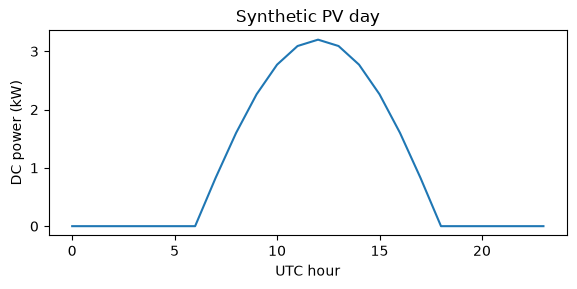

0.02430641316072048 MWh


In [32]:
import numpy as np
import matplotlib.pyplot as plt
# Step 1: Generate a labelled synthetic hourly irradiance profile.
h = np.arange(24); g = np.maximum(0,800*np.sin(np.pi*(h-6)/12))
# Step 2: Convert incident radiation to DC power and energy.
dc_kw = g*20*0.2/1000; energy_mwh = dc_kw.sum()/1000
# Step 3: Plot with units and verify the maximum.
fig,ax=plt.subplots(figsize=(6,3)); ax.plot(h,dc_kw)
ax.set(xlabel='UTC hour',ylabel='DC power (kW)',title='Synthetic PV day'); fig.tight_layout(); plt.show()
print(energy_mwh,'MWh'); assert np.isclose(dc_kw.max(),3.2)

**Interpretation:** The irradiance values are treated as interval means; no real location or date is represented.


### Exercise 16 — Size an inverter by clipping target

**Difficulty:** Hard

**Reference:** PV conversion and systems: [@foster2010; @wade2003]; temperature model [@pvlibDocs].

**Task:** For hourly DC [0,2,5,9,12,8,3,0] kW and 97% efficiency, search integer AC ratings 5–12 kW for at most 5% clipped potential AC energy.

In [33]:
# Your solution for solar exercise 16.

#### Step-by-step answer — Solar 16

1. Calculate the common available AC profile.
2. Evaluate each candidate using the same clipping denominator.
3. Select the smallest rating that satisfies the target.

In [34]:
import numpy as np
# Step 1: Calculate the common available AC profile.
available = np.array([0,2,5,9,12,8,3,0])*0.97
# Step 2: Evaluate each candidate using the same clipping denominator.
trials = [(rating, np.maximum(available-rating,0).sum()/available.sum()) for rating in range(5,13)]
# Step 3: Select the smallest rating that satisfies the target.
best = next(t for t in trials if t[1]<=0.05)
print('Rating kW and clipping fraction:',best)
assert best[0]==10 and all(f>0.05 for r,f in trials if r<best[0])

Rating kW and clipping fraction: (10, 0.043351837166270175)


**Interpretation:** An energy constraint is not a financial optimum; inverter prices and lifetime behavior are omitted.


### Exercise 17 — Temperature and irradiance sensitivity grid

**Difficulty:** Hard

**Reference:** PV conversion and systems: [@foster2010; @wade2003]; temperature model [@pvlibDocs].

**Task:** For G=[200,600,1000] W/m² and ambient=[10,25,40]°C, calculate a 3×3 grid of AC power for 10 kW DC, 8 kW AC, NOCT 45, gamma−0.004 and eta 0.97.

In [35]:
# Your solution for solar exercise 17.

#### Step-by-step answer — Solar 17

1. Broadcast irradiance columns against ambient-temperature rows.
2. Calculate cell temperature, DC and limited AC power.
3. Check bounds and thermal direction and print a labelled grid.

In [36]:
import numpy as np
import pandas as pd
# Step 1: Broadcast irradiance columns against ambient-temperature rows.
g=np.array([200,600,1000])[None,:]; ambient=np.array([10,25,40])[:,None]
# Step 2: Calculate cell temperature, DC and limited AC power.
cell=ambient+g*25/800
dc=np.maximum(10*g/1000*(1-0.004*(cell-25)),0); ac=np.minimum(dc*0.97,8)
# Step 3: Check bounds and thermal direction and print a labelled grid.
assert ac.shape==(3,3) and np.all(ac<=8) and np.all(np.diff(ac,axis=0)<=0)
print(pd.DataFrame(ac,index=[10,25,40],columns=[200,600,1000]).rename_axis('Ambient °C / G W m⁻²'))

                        200     600     1000
Ambient °C / G W m⁻²                        
10                    2.0079  5.7327  8.0000
25                    1.8915  5.3835  8.0000
40                    1.7751  5.0343  7.9055


**Interpretation:** At fixed irradiance, higher modeled cell temperature cannot increase power here; clipping can flatten sensitivity.


### Exercise 18 — PV and battery self-consumption

**Difficulty:** Hard

**Reference:** PV conversion and systems: [@foster2010; @wade2003]; temperature model [@pvlibDocs].

**Task:** PV hourly AC [0,4,6,0] kW meets constant 2 kW load with an initially empty 3 kWh battery, 2 kW limits and 90% efficiencies. Report unmet load, curtailed PV and final SOC.

In [37]:
# Your solution for solar exercise 18.

#### Step-by-step answer — Solar 18

1. Initialise storage and bookkeeping in kWh.
2. Route each one-hour interval through direct use, charging and discharge.
3. Verify storage limits and show final energy accounting.

In [38]:
import numpy as np
# Step 1: Initialise storage and bookkeeping in kWh.
soc=0.; unmet_total=0.; curtailed_total=0.; rows=[]
# Step 2: Route each one-hour interval through direct use, charging and discharge.
for pv in [0,4,6,0]:
    before=soc; direct=min(pv,2)
    charge=min(pv-direct,2,(3-soc)/0.9); discharge=min(2-direct,2,soc*0.9)
    soc+=charge*0.9-discharge/0.9
    unmet=2-direct-discharge; curtailed=pv-direct-charge
    assert np.isclose(before+charge*0.9,soc+discharge/0.9)
    unmet_total+=unmet; curtailed_total+=curtailed; rows.append(soc)
# Step 3: Verify storage limits and show final energy accounting.
print(unmet_total,curtailed_total,soc,'kWh unmet, curtailed, final SOC')
assert np.isclose(unmet_total,2) and all(0<=s<=3+1e-12 for s in rows)

2.0 2.666666666666667 0.7777777777777777 kWh unmet, curtailed, final SOC


**Interpretation:** Stored energy remaining at the end has not yet served the load. Battery economic sizing needs longer data.


### Exercise 19 — PV LCOE with degradation

**Difficulty:** Hard

**Reference:** PV conversion and systems: [@foster2010; @wade2003]; temperature model [@pvlibDocs].

**Task:** Use €1m capital, €20k annual O&M, 1500 MWh first-year AC, 0.5% annual degradation and 25 years. Calculate LCOE at 0%,3%,6% real discount rates.

In [39]:
# Your solution for solar exercise 19.

#### Step-by-step answer — Solar 19

1. Define year-end energy and a reusable discounted-cost calculation.
2. Evaluate the interest-rate scenarios with identical technical inputs.
3. Check the undiscounted result and scenario direction.

In [40]:
import numpy as np
# Step 1: Define year-end energy and a reusable discounted-cost calculation.
years=np.arange(1,26); energy=1500*0.995**(years-1)
def lcoe(rate):
    discount=(1+rate)**years
    return (1_000_000+np.sum(20_000/discount))/np.sum(energy/discount)
# Step 2: Evaluate the interest-rate scenarios with identical technical inputs.
values=[lcoe(r) for r in [0,0.03,0.06]]
# Step 3: Check the undiscounted result and scenario direction.
print(values,'EUR/MWh')
assert np.isclose(values[0],1_500_000/energy.sum()) and np.all(np.diff(values)>0)

[42.45211677441743, 54.36731773613923, 68.49098165375038] EUR/MWh


**Interpretation:** See IFC Chapter 14 and IRENA cost methodology. Costs are synthetic; taxes, replacements and salvage are omitted.


### Exercise 20 — Detect underperformance without future leakage

**Difficulty:** Hard

**Reference:** PV conversion and systems: [@foster2010; @wade2003]; temperature model [@pvlibDocs].

**Task:** Expected daily energy is [10,20,30,40,50,60] kWh; observed is [9,18,27,36,30,36]. Calibrate an observed/expected ratio on days 1–4, then flag holdout days below 80% of calibrated expectation.

In [41]:
# Your solution for solar exercise 20.

#### Step-by-step answer — Solar 20

1. Split the chronological observations before calibration.
2. Estimate one scale factor only from training energy.
3. Flag and check the holdout underperformance.

In [42]:
import numpy as np
# Step 1: Split the chronological observations before calibration.
expected=np.array([10,20,30,40,50,60]); observed=np.array([9,18,27,36,30,36])
train=slice(0,4); test=slice(4,None)
# Step 2: Estimate one scale factor only from training energy.
factor=observed[train].sum()/expected[train].sum()
prediction=expected[test]*factor; relative=observed[test]/prediction
# Step 3: Flag and check the holdout underperformance.
flags=relative<0.8
print('Calibration:',factor,'holdout relative performance:',relative,'flags:',flags)
assert np.isclose(factor,0.9) and flags.all()

Calibration: 0.9 holdout relative performance: [0.66666667 0.66666667] flags: [ True  True]


**Interpretation:** Flags identify a discrepancy, not its cause. Weather-model errors, outages or sensor faults need separate diagnosis.


## Common mistakes

- Confusing irradiance (W/m$^2$) with irradiation (kWh/m$^2$).
- Applying a temperature correction to ambient temperature instead of estimated cell temperature without stating the simplification.
- Omitting inverter clipping or applying system losses twice.
- Summing power without multiplying by the time-step duration.
- Treating the simplified model as a substitute for site-specific shading, orientation, and loss modelling.
- Calling DC nameplate power an energy value.

## Check your understanding

Continue with the [solar quiz and Python challenge](../section7/renewableEnergyquizzes/solarEnergy.md).

## References used in this notebook

- **doePVPerformance:** U.S. Department of Energy. Solar Photovoltaic Performance and Efficiency Basics (2025). https://www.energy.gov/cmei/systems/solar-photovoltaic-performance-and-efficiency-basics
- **doePVLongevity:** U.S. Department of Energy. Optimizing Solar Photovoltaic Performance for Longevity (2025). https://www.energy.gov/cmei/femp/optimizing-solar-photovoltaic-performance-longevity
- **wade2003:** Wade, Herbert A.. Solar Photovoltaic Systems: Technical Training Manual (2003). 
- **foster2010:** Foster, Robert and Ghassemi, Majid and Cota, Alma. Solar Energy: Renewable Energy and the Environment (2010). 
- **pvlibDocs:** pvlib Developers. PVWatts DC Model (2026). https://pvlib-python.readthedocs.io/en/stable/reference/generated/pvlib.pvsystem.pvwatts_dc.html